<a href="https://colab.research.google.com/github/rishabhg46-bot/machine_learning/blob/main/AdaBoostClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [2]:
df=pd.DataFrame()

In [3]:
df['x1']=[1,2,3,4,5,6,6,7,9,9]
df['x2']=[5,3,6,8,1,9,5,8,9,2]
df['label']=[1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

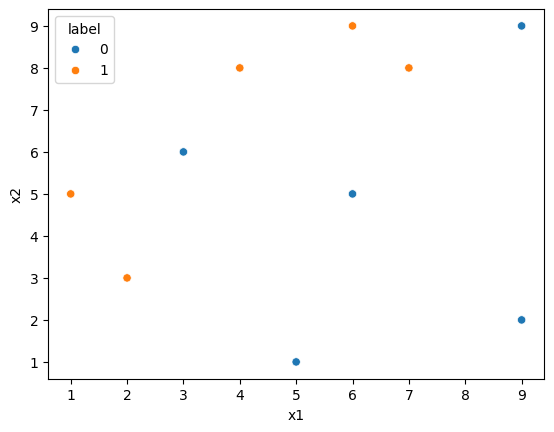

In [8]:
import seaborn as sns
sns.scatterplot(x=df['x1'],y=df['x2'],hue=df['label'])

In [10]:
df['weights']=1/df.shape[0]

In [11]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
dt1=DecisionTreeClassifier(max_depth=1)#in adaboost decision tree are decision stumps

In [13]:
x=df.iloc[:,0:2].values
y=df.iloc[:,2].values

In [14]:
dt1.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]'),
 Text(0.625, 0.5, '  False')]

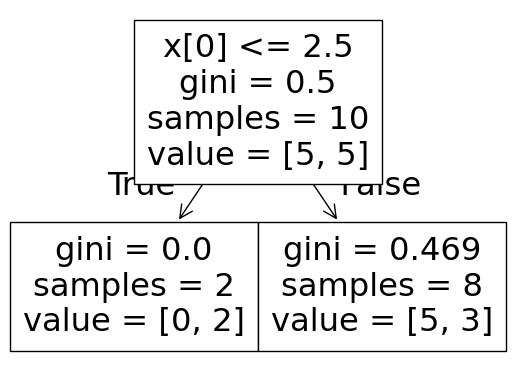

In [15]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

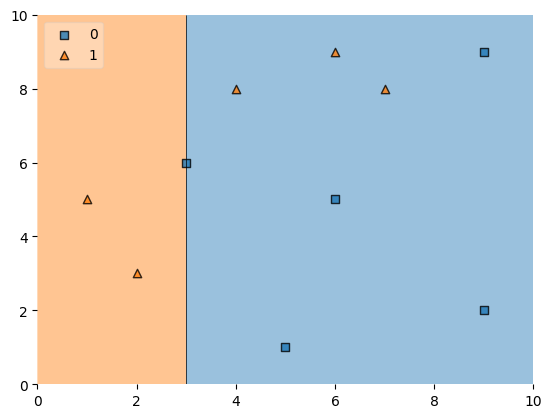

In [17]:
plot_decision_regions(x,y,dt1,legend=2)

In [32]:
df['normalized'] = df['update_weights'] / df['update_weights'].sum()
df.loc[df.index[-1], 'normalized'] = 1 - df['normalized'].iloc[:-1].sum()
#df['normalized'].iloc[:-1].sum(): This part calculates the sum of all normalized values except the very last one.
#1 - ...: By subtracting this sum from 1, we get the exact amount that the last normalized value needs to be for the total sum to be 1.
#df.loc[df.index[-1], 'normalized'] = ...: This then assigns that calculated exact value to the last element of the normalized column, effectively 'correcting' the sum to be precisely 1.0'''

In [19]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [57]:
def calculate_model_weight(error):
   return 0.5*np.log((1-error)/(error+0.0000001))

In [22]:
alpha1=calculate_model_weight( 0.3)
alpha1

np.float64(0.42364893019360184)

In [24]:
#update weights
def update_row_weights(row,alpha=0.423689):
  if row['label']==row['y_pred']:
    return row['weights']*np.exp(-alpha)#
  else:
    return row['weights']*np.exp(alpha)

In [26]:
df['update_weights']=df.apply(update_row_weights,axis=1)

In [28]:
df['update_weights'].sum()

np.float64(0.9165151397269415)

In [30]:
df['normalized']=df['update_weights']/  df['update_weights'].sum()
df

,x1,x2,label,weights,y_pred,update_weights,normalized
0,1,5,1,0.1,1,0.065463,0.071426
1,2,3,1,0.1,1,0.065463,0.071426
2,3,6,0,0.1,0,0.065463,0.071426
3,4,8,1,0.1,0,0.152759,0.166673
4,5,1,0,0.1,0,0.065463,0.071426
5,6,9,1,0.1,0,0.152759,0.166673
6,6,5,0,0.1,0,0.065463,0.071426
7,7,8,1,0.1,0,0.152759,0.166673
8,9,9,0,0.1,0,0.065463,0.071426
9,9,2,0,0.1,0,0.065463,0.071426


In [33]:
df['normalized'].sum()

np.float64(1.0)

In [34]:
df['cumsum_upper']=np.cumsum(df['normalized'])

In [46]:
df['cumsum_lower'] = df['cumsum_upper'].shift(1).fillna(0)

In [37]:
df[['x1','x2','label','weights','y_pred','update_weights','normalized','cumsum_lower','cumsum_upper']]

,x1,x2,label,weights,y_pred,update_weights,normalized,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065463,0.071426,0.071426,0.071426
1,2,3,1,0.1,1,0.065463,0.071426,0.142851,0.142851
2,3,6,0,0.1,0,0.065463,0.071426,0.214277,0.214277
3,4,8,1,0.1,0,0.152759,0.166673,0.380950,0.380950
4,5,1,0,0.1,0,0.065463,0.071426,0.452376,0.452376
5,6,9,1,0.1,0,0.152759,0.166673,0.619050,0.619050
6,6,5,0,0.1,0,0.065463,0.071426,0.690475,0.690475
7,7,8,1,0.1,0,0.152759,0.166673,0.857149,0.857149
8,9,9,0,0.1,0,0.065463,0.071426,0.928574,0.928574
9,9,2,0,0.1,0,0.065463,0.071426,1.000000,1.000000


In [44]:
def create_new_dataset(df):
  indices=[]
  for i in range(df.shape[0]):
    a=np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper']>a and a>row['cumsum_lower']:
        indices.append(index)
  return indices


In [47]:
index_value=create_new_dataset(df)
index_value#upsampling

[7, 2, 7, 9, 7, 8, 9, 9, 7, 9]

In [48]:
second_df=df.iloc[index_value,[0,1,2,3]]
second_df

,x1,x2,label,weights
7,7,8,1,0.1
2,3,6,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
7,7,8,1,0.1
9,9,2,0,0.1


In [50]:
dt2=DecisionTreeClassifier(max_depth=1)
dt2

DecisionTreeClassifier(max_depth=1)

In [51]:
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values

In [52]:
dt2.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

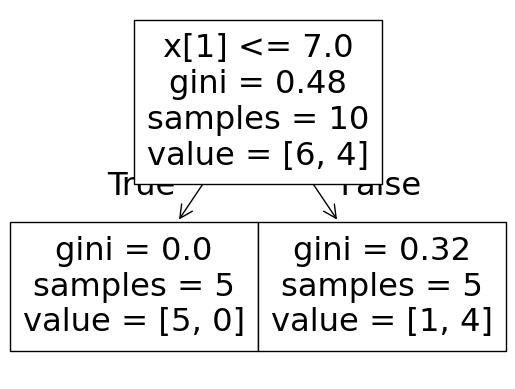

In [53]:
plot_tree(dt2)

<Axes: >

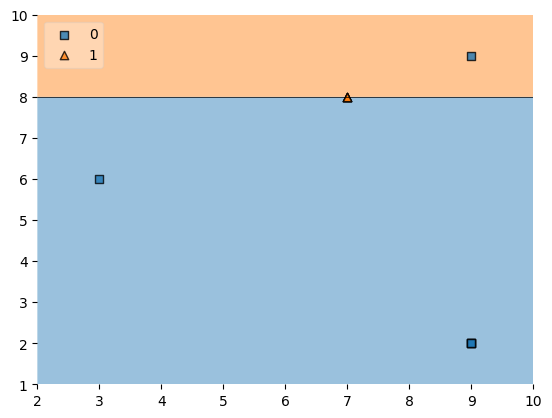

In [54]:
plot_decision_regions(x,y,dt2,legend=2)

In [55]:
second_df['y_pred']=dt2.predict(x)
second_df

,x1,x2,label,weights,y_pred
7,7,8,1,0.1,1
2,3,6,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0
9,9,2,0,0.1,0
7,7,8,1,0.1,1
9,9,2,0,0.1,0


In [56]:
alpha2=calculate_model_weight(0.1)
alpha2

np.float64(1.0986122886681098)

In [58]:
#update weights
def update_row_weights(row,alpha=1.098):
  if row['label']==row['y_pred']:
    return row['weights']*np.exp(-alpha)#
  else:
    return row['weights']*np.exp(alpha)

In [61]:
second_df['update_weights']=second_df.apply(update_row_weights,axis=1)

In [68]:
second_df['normalized']=second_df['update_weights']/second_df['update_weights'].sum()
second_df

,x1,x2,label,weights,y_pred,update_weights,noemlized,normlized,normalized
7,7,8,1,0.1,1,0.033354,0.055590,0.055590,0.055590
2,3,6,0,0.1,0,0.033354,0.055590,0.055590,0.055590
7,7,8,1,0.1,1,0.033354,0.055590,0.055590,0.055590
9,9,2,0,0.1,0,0.033354,0.055590,0.055590,0.055590
7,7,8,1,0.1,1,0.033354,0.055590,0.055590,0.055590
8,9,9,0,0.1,1,0.299816,0.499694,0.499694,0.499694
9,9,2,0,0.1,0,0.033354,0.055590,0.055590,0.055590
9,9,2,0,0.1,0,0.033354,0.055590,0.055590,0.055590
7,7,8,1,0.1,1,0.033354,0.055590,0.055590,0.055590
9,9,2,0,0.1,0,0.033354,0.055590,0.055590,0.055590


In [69]:
second_df['normalized'].sum()

np.float64(1.0)

In [70]:
second_df['cumsum_upper']=np.cumsum(second_df['normalized'])

In [71]:
second_df['cumsum_lower'] = second_df['cumsum_upper'].shift(1).fillna(0)

In [72]:
index_value=create_new_dataset(second_df)
index_value#upsampling

[7, 8, 8, 8, 8, 9, 9, 8, 8, 8]

In [73]:
third_df=df.iloc[index_value,[0,1,2,3]]
third_df

,x1,x2,label,weights
7,7,8,1,0.1
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
9,9,2,0,0.1
9,9,2,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1
8,9,9,0,0.1


In [75]:
dt3=DecisionTreeClassifier(max_depth=1)
x=second_df.iloc[:,0:2].values
y=second_df.iloc[:,2].values
dt3.fit(x,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.32\nsamples = 5\nvalue = [1, 4]'),
 Text(0.625, 0.5, '  False')]

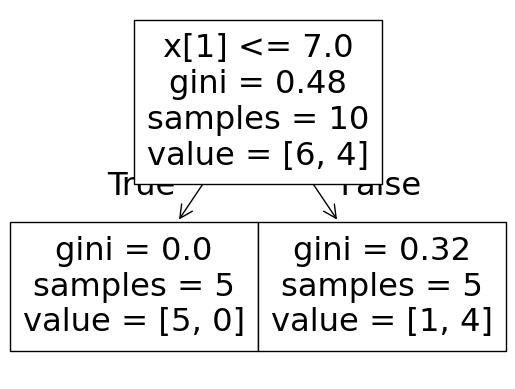

In [76]:
plot_tree(dt3)

<Axes: >

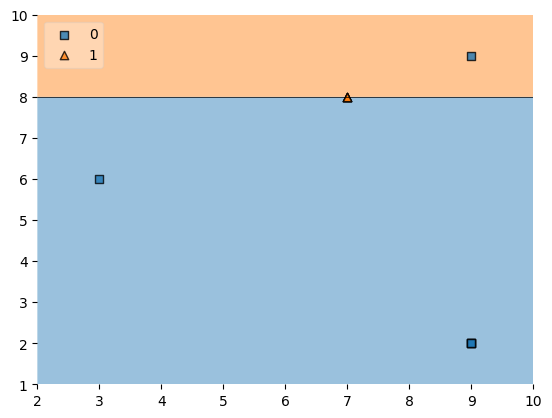

In [77]:
plot_decision_regions(x,y,dt3,legend=2)

In [78]:
third_df['y_pred']=dt2.predict(x)
third_df

,x1,x2,label,weights,y_pred
7,7,8,1,0.1,1
8,9,9,0,0.1,0
8,9,9,0,0.1,1
8,9,9,0,0.1,0
8,9,9,0,0.1,1
9,9,2,0,0.1,1
9,9,2,0,0.1,0
8,9,9,0,0.1,0
8,9,9,0,0.1,1
8,9,9,0,0.1,0


In [79]:
alpha3=calculate_model_weight(0.4)
alpha3

np.float64(0.20273242905409775)

In [82]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 0.20273242905409775


In [85]:
query=np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [86]:
dt2.predict(query)#in case of boosting 0 will be consider as -1

array([0])

In [87]:
dt3.predict(query)

array([0])

In [97]:
alpha1*dt1.predict(query)+alpha2*dt2.predict(query)+alpha3*dt3.predict(query)

array([1.30134472])

In [98]:
np.sign(1.30134472)

np.float64(1.0)

In [92]:
query=np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [93]:
dt2.predict(query)

array([1])

In [99]:
np.sign(alpha1*dt1.predict(query)+alpha2*dt2.predict(query)+alpha3*dt3.predict(query))

array([1.])

ADABOOST CLASS


In [100]:

class AdaBoostClassifier:
    def __init__(self, n_estimators=5):
        self.n_estimators = n_estimators
        self.stumps = []
        self.alphas = []

    def _calculate_model_weight(self, error):
        # Add a small epsilon to avoid division by zero or log of zero
        return 0.5 * np.log((1 - error) / (error + 1e-10))

    def _update_row_weights(self, row, alpha):
        if row['label'] == row['y_pred']:
            return row['weights'] * np.exp(-alpha)
        else:
            return row['weights'] * np.exp(alpha)

    def _create_new_dataset(self, df):
        indices = []
        for _ in range(df.shape[0]):
            a = np.random.random()
            for index, row_data in df.iterrows():
                if row_data['cumsum_upper'] > a and a >= row_data['cumsum_lower']:
                    indices.append(index)
                    break # Found the bucket, move to the next random number
        return indices

    def fit(self, X, y):
        self.stumps = []
        self.alphas = []

        # Initialize weights
        df = pd.DataFrame(X, columns=['x1', 'x2'])
        df['label'] = y
        df['weights'] = 1 / df.shape[0]

        for i in range(self.n_estimators):
            # 1. Train a weak learner (decision stump)
            dt = DecisionTreeClassifier(max_depth=1)
            dt.fit(df[['x1', 'x2']].values, df['label'].values, sample_weight=df['weights'].values)
            y_pred = dt.predict(df[['x1', 'x2']].values)

            # Store stump
            self.stumps.append(dt)

            # 2. Calculate error
            error = sum(df['weights'][df['label'] != y_pred]) / sum(df['weights'])

            # Handle edge cases for error
            if error == 0:
                alpha = 10000.0 # Assign a very large weight if perfect prediction
            elif error >= 0.5:
                break # Stop if performance is worse than random
            else:
                # 3. Calculate model weight (alpha)
                alpha = self._calculate_model_weight(error)
            self.alphas.append(alpha)

            # 4. Update sample weights
            df['y_pred'] = y_pred
            df['update_weights'] = df.apply(lambda row: self._update_row_weights(row, alpha), axis=1)

            # 5. Normalize sample weights
            df['weights'] = df['update_weights'] / df['update_weights'].sum()

            # If it's not the last estimator, prepare for next iteration by resampling
            if i < self.n_estimators - 1:
                df['cumsum_upper'] = np.cumsum(df['weights'])
                df['cumsum_lower'] = df['cumsum_upper'].shift(1).fillna(0)

                # Create new dataset by resampling
                indices = self._create_new_dataset(df)
                df = df.iloc[indices].reset_index(drop=True)
                df['weights'] = 1 / df.shape[0] # Reinitialize weights for the resampled dataframe for the next stump

    def predict(self, X):
        final_predictions = np.zeros(X.shape[0])
        for i, stump in enumerate(self.stumps):
            predictions = stump.predict(X)
            # Convert 0 to -1 for Adaboost's weighted sum
            predictions[predictions == 0] = -1
            final_predictions += self.alphas[i] * predictions

        # Convert sum back to 0 or 1 classification
        return np.sign(final_predictions)





In [101]:
# Prepare the data for the AdaBoostClassifier
X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

# Instantiate and train the AdaBoostClassifier
adaboost_model = AdaBoostClassifier(n_estimators=3) # You can adjust n_estimators
adaboost_model.fit(X, y)

print("AdaBoost model trained successfully!")

AdaBoost model trained successfully!


In [102]:
# Example 1: Predict for an existing data point [1,5] (which was originally label 1)
query1 = np.array([1, 5]).reshape(1, 2)
prediction1 = adaboost_model.predict(query1)
print(f"Prediction for {query1[0]}: {prediction1[0]} (Original label: 1)")

# Example 2: Predict for another existing data point [9,9] (which was originally label 0)
query2 = np.array([9, 9]).reshape(1, 2)
prediction2 = adaboost_model.predict(query2)
print(f"Prediction for {query2[0]}: {prediction2[0]} (Original label: 0)")

Prediction for [1 5]: 1.0 (Original label: 1)
Prediction for [9 9]: 1.0 (Original label: 0)
